# Evaluation of background shift experiment

- The notebook uses the evaluation **paired compare CSVs**, so all metrics are computed against the original source images.
- `mean_delta_prob_correct < 0` means the model became less confident in the correct class after relocation.
- `pred_changed_rate` measures how often the generated image changed the model's top-1 prediction relative to the original image.
- If a model tag does not match your actual CSV filenames, adjust `MODEL_TAGS` in the configuration cell.

#### Import packages

In [1]:

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams.update({
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], 
})

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)


#### Configuration

In [2]:

# ===== USER SETTINGS =====
EXPERIMENT_ROOT = Path("/data/local/rgaisina/experiments_final/object_relocation_background_shift")
META_DIR = EXPERIMENT_ROOT / "meta"
ANALYSIS_DIR = EXPERIMENT_ROOT / "eval_results_1"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

TOPK = 5

# Display name -> model tag used in CSV filenames
# Adapt these tags to the exact filenames written by your evaluator.
MODEL_TAGS = {
    "ResNet-18": "resnet18_a1_in1k",
    "ResNet-50": "resnet50_a1_in1k",
    "ViT-Tiny": "vit_tiny_patch16_224_augreg_in21k_ft_in1k",
    "ViT-Base": "vit_base_patch16_224_augreg_in21k_ft_in1k",
    # Examples if you evaluated augreg variants:
    # "ViT-Tiny AugReg": "vit_tiny_patch16_224_augreg_in21k_ft_in1k",
    # "ViT-Base AugReg": "vit_base_patch16_224_augreg_in21k_ft_in1k",
}

BACKGROUND_ORDER = ["openwater", "surface"]
SAVE_FIGURES = True
SHOW_PLOTS = True

print("Experiment root:", EXPERIMENT_ROOT)
print("Meta dir:", META_DIR)
print("Analysis dir:", ANALYSIS_DIR)
print("TOPK:", TOPK)
print("Models:", list(MODEL_TAGS.keys()))


Experiment root: /data/local/rgaisina/experiments_final/object_relocation_background_shift
Meta dir: /data/local/rgaisina/experiments_final/object_relocation_background_shift/meta
Analysis dir: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1
TOPK: 5
Models: ['ResNet-18', 'ResNet-50', 'ViT-Tiny', 'ViT-Base']


#### Helpers

In [3]:

def find_compare_csv(meta_dir: Path, model_tag: str, topk: int = 5) -> Path:
    patterns = [
        f"eval_compare_*_{model_tag}_top{topk}.csv",
        f"*compare*{model_tag}*top{topk}*.csv",
    ]
    matches = []
    for pattern in patterns:
        matches.extend(sorted(meta_dir.glob(pattern)))
    # de-duplicate while preserving order
    seen = set()
    uniq = []
    for p in matches:
        if p not in seen:
            uniq.append(p)
            seen.add(p)
    if not uniq:
        raise FileNotFoundError(f"No compare CSV found for model_tag={model_tag} in {meta_dir}")
    if len(uniq) > 1:
        print(f"[WARN] Multiple compare CSVs found for {model_tag}; using first:")
        for p in uniq:
            print("  ", p.name)
    return uniq[0]

def ensure_numeric(df: pd.DataFrame, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def save_table(df: pd.DataFrame, stem: str):
    csv_path = ANALYSIS_DIR / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

def save_figure(fig, stem: str):
    out = ANALYSIS_DIR / f"{stem}.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print("Saved:", out)

def grouped_bar(ax, categories, series_dict, title="", ylabel="", ylim=None, as_percent=False, rotation=0):
    labels = list(categories)
    names = list(series_dict.keys())
    x = np.arange(len(labels))
    width = 0.8 / max(1, len(names))
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, len(names)) if len(names) > 1 else [0.0]

    for off, name in zip(offsets, names):
        vals = [series_dict[name].get(cat, np.nan) for cat in labels]
        if as_percent:
            values_plot = [v * 100 if not np.isnan(v) else np.nan for v in vals]
        else:
            values_plot = vals
        bars = ax.bar(x + off, values_plot, width=width, label=name)
        
        ax.bar_label(
            bars,
            labels=[f"{v:.2f}" if not np.isnan(v) else "" for v in values_plot],
            padding=2,
            fontsize=14
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotation)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()

def sort_classes_by_reference_metric(df, reference_model=None, metric="generated_top1_acc"):
    if reference_model is None:
        reference_model = sorted(df["model_display"].unique())[0]
    ref = (
        df[df["model_display"] == reference_model][["class_name", metric]]
        .sort_values(metric, ascending=False)
    )
    return ref["class_name"].tolist()

def annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.01):
    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if np.isnan(height):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_offset * y_span,
                fmt.format(height),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                clip_on=False,
            )

#### Load compare CSVs for all models

In [4]:

compare_frames = []
csv_registry = []

for model_display, model_tag in MODEL_TAGS.items():
    csv_path = find_compare_csv(META_DIR, model_tag=model_tag, topk=TOPK)
    df = pd.read_csv(csv_path)

    numeric_cols = [
        "original_correct_in_top1",
        "generated_correct_in_top1",
        "original_correct_in_top5",
        "generated_correct_in_top5",
        "original_correct_rank",
        "generated_correct_rank",
        "original_prob_correct",
        "generated_prob_correct",
        "delta_prob_correct",
        "original_logit_correct",
        "generated_logit_correct",
        "delta_logit_correct",
        "pred_changed_vs_original",
    ]
    df = ensure_numeric(df, numeric_cols)

    df["model_display"] = model_display
    df["model_tag"] = model_tag
    compare_frames.append(df)

    csv_registry.append({
        "model_display": model_display,
        "model_tag": model_tag,
        "csv_path": str(csv_path),
        "n_rows": len(df),
    })

compare_df = pd.concat(compare_frames, ignore_index=True)
registry_df = pd.DataFrame(csv_registry)

display(registry_df)
print("Combined rows:", len(compare_df))
print("Backgrounds:", sorted(compare_df["background_name"].dropna().unique().tolist()))
print("Classes:", len(compare_df["class_name"].dropna().unique()))


[WARN] Multiple compare CSVs found for resnet18_a1_in1k; using first:
   eval_compare_background_shift_resnet18_a1_in1k_top5.csv
   eval_compare_background_shift_resnet18_a1_in1k_top5_summary.csv
[WARN] Multiple compare CSVs found for resnet50_a1_in1k; using first:
   eval_compare_background_shift_resnet50_a1_in1k_top5.csv
   eval_compare_background_shift_resnet50_a1_in1k_top5_summary.csv
[WARN] Multiple compare CSVs found for vit_tiny_patch16_224_augreg_in21k_ft_in1k; using first:
   eval_compare_background_shift_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5.csv
   eval_compare_background_shift_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5_summary.csv
[WARN] Multiple compare CSVs found for vit_base_patch16_224_augreg_in21k_ft_in1k; using first:
   eval_compare_background_shift_vit_base_patch16_224_augreg_in21k_ft_in1k_top5.csv
   eval_compare_background_shift_vit_base_patch16_224_augreg_in21k_ft_in1k_top5_summary.csv


,model_display,model_tag,csv_path,n_rows
0,ResNet-18,resnet18_a1_in1k,/data/local/rgaisina/experiments_final/object_...,110
1,ResNet-50,resnet50_a1_in1k,/data/local/rgaisina/experiments_final/object_...,110
2,ViT-Tiny,vit_tiny_patch16_224_augreg_in21k_ft_in1k,/data/local/rgaisina/experiments_final/object_...,110
3,ViT-Base,vit_base_patch16_224_augreg_in21k_ft_in1k,/data/local/rgaisina/experiments_final/object_...,110


Combined rows: 440
Backgrounds: ['openwater', 'surface']
Classes: 11


In [5]:
save_table(registry_df, "loaded_compare_csv_registry")

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/loaded_compare_csv_registry.csv


#### Overall summary by model

In [6]:

overall_model = (
    compare_df.groupby(["model_display", "model_tag"], as_index=False)
    .agg(
        n=("source_image_id", "size"),
        original_top1_acc=("original_correct_in_top1", "mean"),
        generated_top1_acc=("generated_correct_in_top1", "mean"),
        original_top5_acc=("original_correct_in_top5", "mean"),
        generated_top5_acc=("generated_correct_in_top5", "mean"),
        mean_original_prob_correct=("original_prob_correct", "mean"),
        mean_generated_prob_correct=("generated_prob_correct", "mean"),
        mean_delta_prob_correct=("delta_prob_correct", "mean"),
        mean_original_rank=("original_correct_rank", "mean"),
        mean_generated_rank=("generated_correct_rank", "mean"),
        pred_changed_rate=("pred_changed_vs_original", "mean"),
    )
)

overall_model["delta_top1_acc"] = overall_model["generated_top1_acc"] - overall_model["original_top1_acc"]
overall_model["delta_top5_acc"] = overall_model["generated_top5_acc"] - overall_model["original_top5_acc"]

overall_model = overall_model.sort_values("generated_top1_acc", ascending=False).reset_index(drop=True)
display(overall_model)
save_table(overall_model, "overall_summary_by_model")


,model_display,model_tag,n,original_top1_acc,generated_top1_acc,original_top5_acc,generated_top5_acc,mean_original_prob_correct,mean_generated_prob_correct,mean_delta_prob_correct,mean_original_rank,mean_generated_rank,pred_changed_rate,delta_top1_acc,delta_top5_acc
0,ViT-Base,vit_base_patch16_224_augreg_in21k_ft_in1k,110,1.0,0.836364,1.0,0.981818,0.894725,0.655982,-0.238743,1.0,1.754545,0.163636,-0.163636,-0.018182
1,ResNet-50,resnet50_a1_in1k,110,1.0,0.736364,1.0,0.954545,0.947225,0.675528,-0.271697,1.0,1.881818,0.263636,-0.263636,-0.045455
2,ResNet-18,resnet18_a1_in1k,110,1.0,0.545455,1.0,0.854545,0.884830,0.420318,-0.464512,1.0,4.436364,0.454545,-0.454545,-0.145455
3,ViT-Tiny,vit_tiny_patch16_224_augreg_in21k_ft_in1k,110,1.0,0.518182,1.0,0.772727,0.854166,0.392675,-0.461491,1.0,9.472727,0.481818,-0.481818,-0.227273


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/overall_summary_by_model.csv


#### Summary by background and model

In [7]:

background_model = (
    compare_df.groupby(["background_name", "model_display", "model_tag"], as_index=False)
    .agg(
        n=("source_image_id", "size"),
        original_top1_acc=("original_correct_in_top1", "mean"),
        generated_top1_acc=("generated_correct_in_top1", "mean"),
        original_top5_acc=("original_correct_in_top5", "mean"),
        generated_top5_acc=("generated_correct_in_top5", "mean"),
        mean_original_prob_correct=("original_prob_correct", "mean"),
        mean_generated_prob_correct=("generated_prob_correct", "mean"),
        mean_delta_prob_correct=("delta_prob_correct", "mean"),
        mean_generated_rank=("generated_correct_rank", "mean"),
        pred_changed_rate=("pred_changed_vs_original", "mean"),
    )
)

background_model["delta_top1_acc"] = background_model["generated_top1_acc"] - background_model["original_top1_acc"]
background_model["delta_top5_acc"] = background_model["generated_top5_acc"] - background_model["original_top5_acc"]

background_model["background_name"] = pd.Categorical(
    background_model["background_name"],
    categories=BACKGROUND_ORDER,
    ordered=True,
)
background_model = background_model.sort_values(["background_name", "generated_top1_acc"], ascending=[True, False]).reset_index(drop=True)

display(background_model)
save_table(background_model, "summary_by_background_and_model")


,background_name,model_display,model_tag,n,original_top1_acc,generated_top1_acc,original_top5_acc,generated_top5_acc,mean_original_prob_correct,mean_generated_prob_correct,mean_delta_prob_correct,mean_generated_rank,pred_changed_rate,delta_top1_acc,delta_top5_acc
0,openwater,ViT-Base,vit_base_patch16_224_augreg_in21k_ft_in1k,55,1.0,0.836364,1.0,0.981818,0.894725,0.615469,-0.279255,2.200000,0.163636,-0.163636,-0.018182
1,openwater,ResNet-50,resnet50_a1_in1k,55,1.0,0.727273,1.0,0.927273,0.947225,0.626525,-0.320700,2.218182,0.272727,-0.272727,-0.072727
2,openwater,ViT-Tiny,vit_tiny_patch16_224_augreg_in21k_ft_in1k,55,1.0,0.527273,1.0,0.727273,0.854166,0.364590,-0.489575,12.036364,0.472727,-0.472727,-0.272727
3,openwater,ResNet-18,resnet18_a1_in1k,55,1.0,0.436364,1.0,0.800000,0.884830,0.339939,-0.544891,6.254545,0.563636,-0.563636,-0.200000
4,surface,ViT-Base,vit_base_patch16_224_augreg_in21k_ft_in1k,55,1.0,0.836364,1.0,0.981818,0.894725,0.696494,-0.198230,1.309091,0.163636,-0.163636,-0.018182
5,surface,ResNet-50,resnet50_a1_in1k,55,1.0,0.745455,1.0,0.981818,0.947225,0.724530,-0.222695,1.545455,0.254545,-0.254545,-0.018182
6,surface,ResNet-18,resnet18_a1_in1k,55,1.0,0.654545,1.0,0.909091,0.884830,0.500697,-0.384133,2.618182,0.345455,-0.345455,-0.090909
7,surface,ViT-Tiny,vit_tiny_patch16_224_augreg_in21k_ft_in1k,55,1.0,0.509091,1.0,0.818182,0.854166,0.420760,-0.433406,6.909091,0.490909,-0.490909,-0.181818


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/summary_by_background_and_model.csv


#### Summary by class and model

In [8]:

class_model = (
    compare_df.groupby(["class_name", "model_display", "model_tag"], as_index=False)
    .agg(
        n=("source_image_id", "size"),
        original_top1_acc=("original_correct_in_top1", "mean"),
        generated_top1_acc=("generated_correct_in_top1", "mean"),
        original_top5_acc=("original_correct_in_top5", "mean"),
        generated_top5_acc=("generated_correct_in_top5", "mean"),
        mean_original_prob_correct=("original_prob_correct", "mean"),
        mean_generated_prob_correct=("generated_prob_correct", "mean"),
        mean_delta_prob_correct=("delta_prob_correct", "mean"),
        mean_generated_rank=("generated_correct_rank", "mean"),
        pred_changed_rate=("pred_changed_vs_original", "mean"),
    )
)

class_model["delta_top1_acc"] = class_model["generated_top1_acc"] - class_model["original_top1_acc"]
class_model["delta_top5_acc"] = class_model["generated_top5_acc"] - class_model["original_top5_acc"]

display(class_model.head())
save_table(class_model, "summary_by_class_and_model")


,class_name,model_display,model_tag,n,original_top1_acc,generated_top1_acc,original_top5_acc,generated_top5_acc,mean_original_prob_correct,mean_generated_prob_correct,mean_delta_prob_correct,mean_generated_rank,pred_changed_rate,delta_top1_acc,delta_top5_acc
0,african_elephant,ResNet-18,resnet18_a1_in1k,10,1.0,0.7,1.0,1.0,0.784359,0.441019,-0.343340,1.4,0.3,-0.3,0.0
1,african_elephant,ResNet-50,resnet50_a1_in1k,10,1.0,1.0,1.0,1.0,0.881983,0.915830,0.033847,1.0,0.0,0.0,0.0
2,african_elephant,ViT-Base,vit_base_patch16_224_augreg_in21k_ft_in1k,10,1.0,0.8,1.0,1.0,0.777785,0.549967,-0.227818,1.3,0.2,-0.2,0.0
3,african_elephant,ViT-Tiny,vit_tiny_patch16_224_augreg_in21k_ft_in1k,10,1.0,0.7,1.0,1.0,0.731022,0.555450,-0.175572,1.4,0.3,-0.3,0.0
4,airliner,ResNet-18,resnet18_a1_in1k,10,1.0,0.4,1.0,0.6,0.990223,0.237899,-0.752324,7.6,0.6,-0.6,-0.4


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/summary_by_class_and_model.csv


#### Pivot tables for easier comparison

In [9]:

pivot_bg_top1 = background_model.pivot(index="background_name", columns="model_display", values="generated_top1_acc").reset_index()
pivot_bg_top5 = background_model.pivot(index="background_name", columns="model_display", values="generated_top5_acc").reset_index()
pivot_bg_delta_prob = background_model.pivot(index="background_name", columns="model_display", values="mean_delta_prob_correct").reset_index()
pivot_bg_changed = background_model.pivot(index="background_name", columns="model_display", values="pred_changed_rate").reset_index()

display(pivot_bg_top1)
display(pivot_bg_delta_prob)

save_table(pivot_bg_top1, "pivot_background_generated_top1")
save_table(pivot_bg_top5, "pivot_background_generated_top5")
save_table(pivot_bg_delta_prob, "pivot_background_mean_delta_prob")
save_table(pivot_bg_changed, "pivot_background_pred_changed_rate")


model_display,background_name,ResNet-18,ResNet-50,ViT-Base,ViT-Tiny
0,openwater,0.436364,0.727273,0.836364,0.527273
1,surface,0.654545,0.745455,0.836364,0.509091


model_display,background_name,ResNet-18,ResNet-50,ViT-Base,ViT-Tiny
0,openwater,-0.544891,-0.320700,-0.279255,-0.489575
1,surface,-0.384133,-0.222695,-0.198230,-0.433406


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_background_generated_top1.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_background_generated_top5.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_background_mean_delta_prob.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_background_pred_changed_rate.csv


In [10]:

class_order = sort_classes_by_reference_metric(class_model, metric="generated_top1_acc")

pivot_class_top1 = (
    class_model.pivot(index="class_name", columns="model_display", values="generated_top1_acc")
    .reindex(class_order)
    .reset_index()
)
pivot_class_delta_prob = (
    class_model.pivot(index="class_name", columns="model_display", values="mean_delta_prob_correct")
    .reindex(class_order)
    .reset_index()
)

display(pivot_class_top1.head(10))
save_table(pivot_class_top1, "pivot_class_generated_top1")
save_table(pivot_class_delta_prob, "pivot_class_mean_delta_prob")


model_display,class_name,ResNet-18,ResNet-50,ViT-Base,ViT-Tiny
0,hen_bird,0.9,0.9,1.0,1.0
1,catamaran_boat,0.8,0.5,0.7,0.5
2,rocking_chair,0.8,1.0,1.0,0.9
3,african_elephant,0.7,1.0,0.8,0.7
4,tandem_bicycle,0.7,0.8,0.9,0.6
5,convertible_car,0.6,0.9,1.0,0.4
6,airliner,0.4,0.5,1.0,0.1
7,borzoi_dog,0.4,0.9,0.8,0.7
8,garbage_truck,0.3,0.8,1.0,0.0
9,tabby_cat,0.3,0.3,0.0,0.0


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_class_generated_top1.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/pivot_class_mean_delta_prob.csv


#### Overall model comparison

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_overall_model_comparison.png


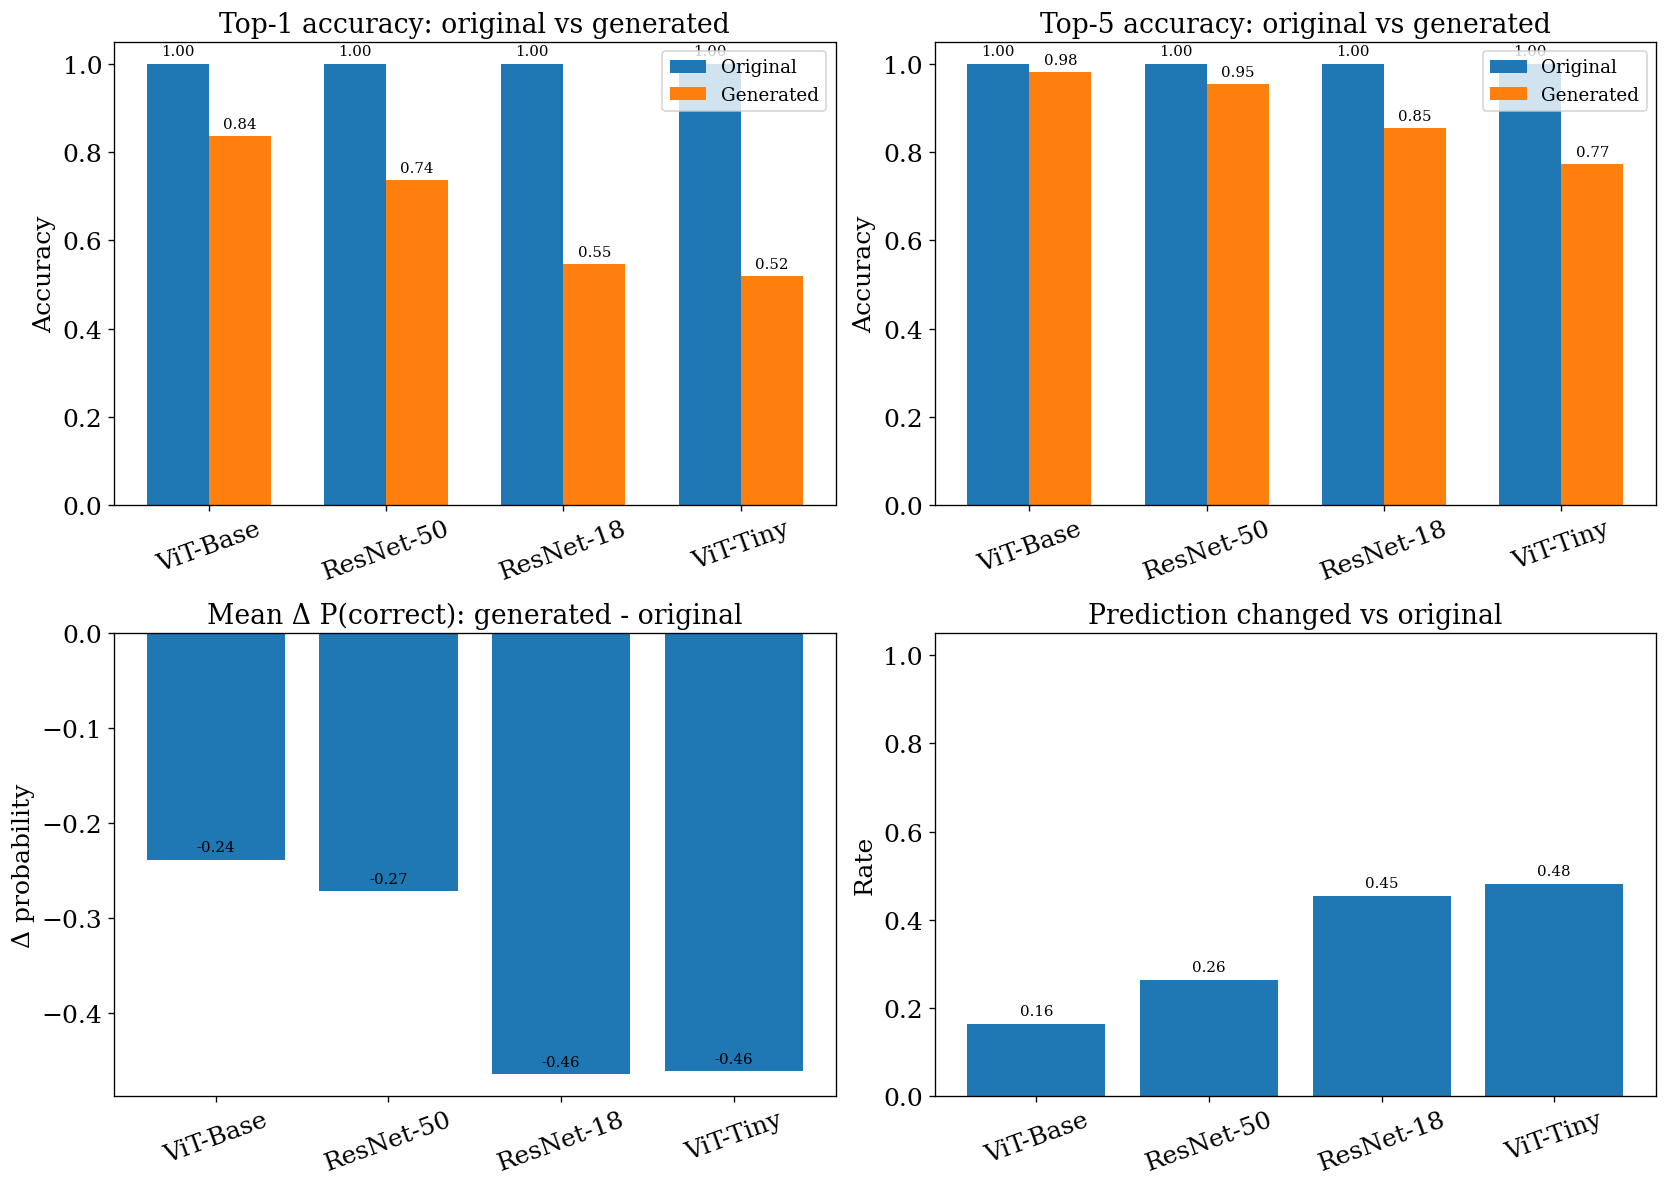

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

overall_plot = overall_model.copy()
labels = overall_plot["model_display"].tolist()
x = np.arange(len(labels))
width = 0.35

# Top-1
axes[0].bar(x - width/2, overall_plot["original_top1_acc"], width=width, label="Original")
axes[0].bar(x + width/2, overall_plot["generated_top1_acc"], width=width, label="Generated")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Top-1 accuracy: original vs generated")
annotate_bars(axes[0], fmt='{:.2f}', fontsize=9, y_offset=0.012)
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Top-5
axes[1].bar(x - width/2, overall_plot["original_top5_acc"], width=width, label="Original")
axes[1].bar(x + width/2, overall_plot["generated_top5_acc"], width=width, label="Generated")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylim(0, 1.05)
axes[1].set_title(f"Top-{TOPK} accuracy: original vs generated")
annotate_bars(axes[1], fmt='{:.2f}', fontsize=9, y_offset=0.012)
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Mean delta probability
axes[2].bar(x, overall_plot["mean_delta_prob_correct"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=20)
axes[2].set_title("Mean Δ P(correct): generated - original")
annotate_bars(axes[2], fmt='{:.2f}', fontsize=9, y_offset=0.012)
axes[2].set_ylabel("Δ probability")

# Prediction changed rate
axes[3].bar(x, overall_plot["pred_changed_rate"])
axes[3].set_xticks(x)
axes[3].set_xticklabels(labels, rotation=20)
axes[3].set_ylim(0, 1.05)
axes[3].set_title("Prediction changed vs original")
annotate_bars(axes[3], fmt='{:.2f}', fontsize=9, y_offset=0.012)
axes[3].set_ylabel("Rate")

plt.tight_layout()

if SAVE_FIGURES:
    save_figure(fig, "fig_overall_model_comparison")
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)


#### Background-wise comparison

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_bg_top1.png


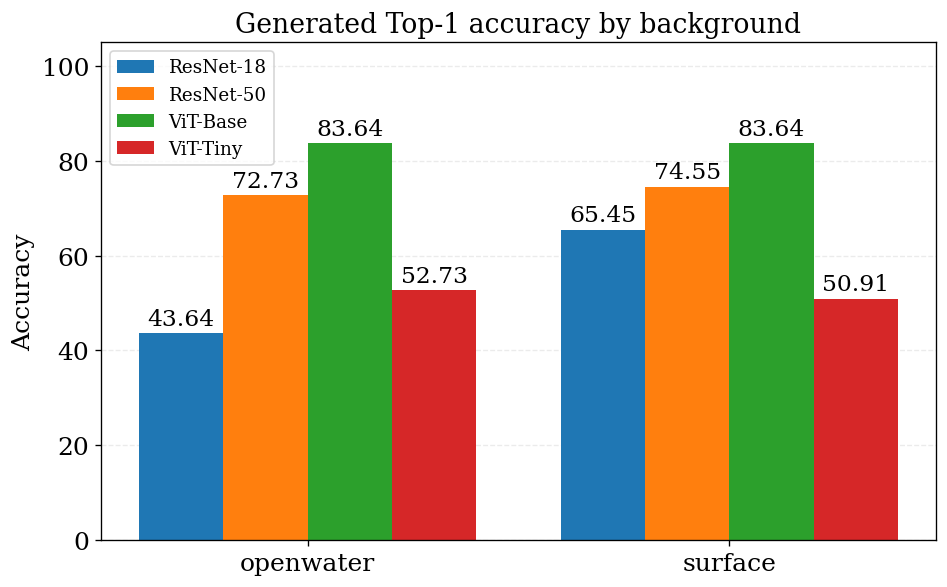

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_bg_top5.png


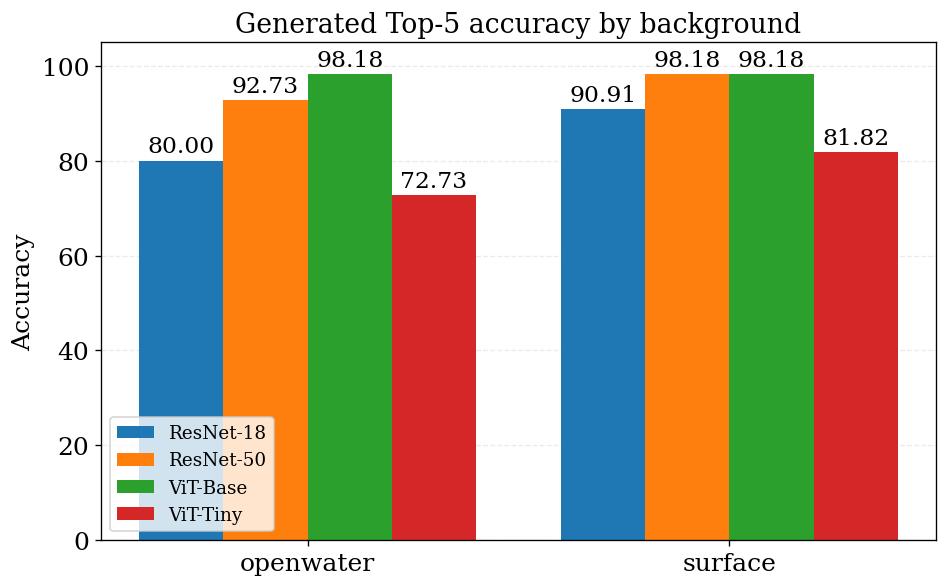

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_bg_delta_prob.png


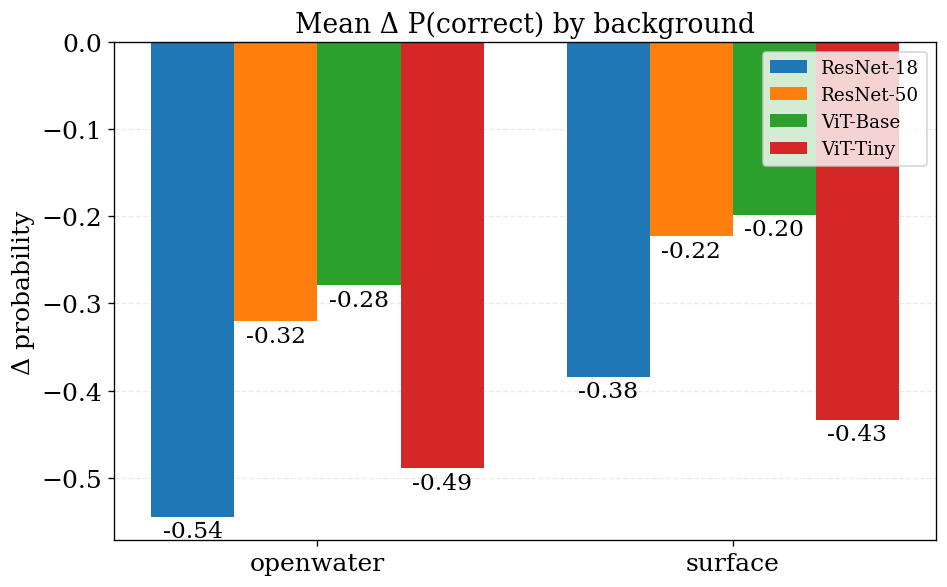

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_bg_change_rate.png


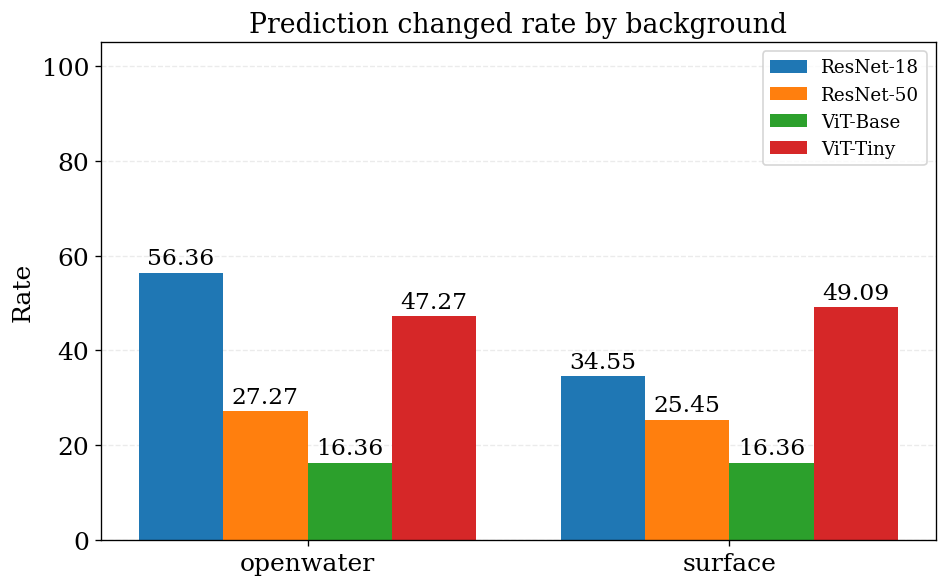

In [14]:
# Prepare series dicts for grouped bar charts
def metric_series_by_model(df, metric):
    out = {}
    for model in sorted(df["model_display"].unique()):
        part = df[df["model_display"] == model]
        out[model] = {row["background_name"]: row[metric] for _, row in part.iterrows()}
    return out


plots = [
    ("generated_top1_acc", "Generated Top-1 accuracy by background", "Accuracy", (0, 105), True, "fig_bg_top1"),
    ("generated_top5_acc", f"Generated Top-{TOPK} accuracy by background", "Accuracy", (0, 105), True, "fig_bg_top5"),
    ("mean_delta_prob_correct", "Mean Δ P(correct) by background", "Δ probability", None, False, "fig_bg_delta_prob"),
    ("pred_changed_rate", "Prediction changed rate by background", "Rate", (0, 105), True, "fig_bg_change_rate"),
]


for metric, title, ylabel, ylim, as_percent, filename in plots:
    fig, ax = plt.subplots(figsize=(8, 5))

    grouped_bar(
        ax,
        BACKGROUND_ORDER,
        metric_series_by_model(background_model, metric),
        title=title,
        ylabel=ylabel,
        ylim=ylim,
        as_percent=as_percent,
    )

    # ✅ Force ALL borders (spines) to be visible
    for spine in ax.spines.values():
        spine.set_visible(True)

    # Optional: slightly cleaner grid (but keep subtle)
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()

    if SAVE_FIGURES:
        save_figure(fig, filename)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

#### Class-wise comparison

Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/fig_classwise_model_comparison.png


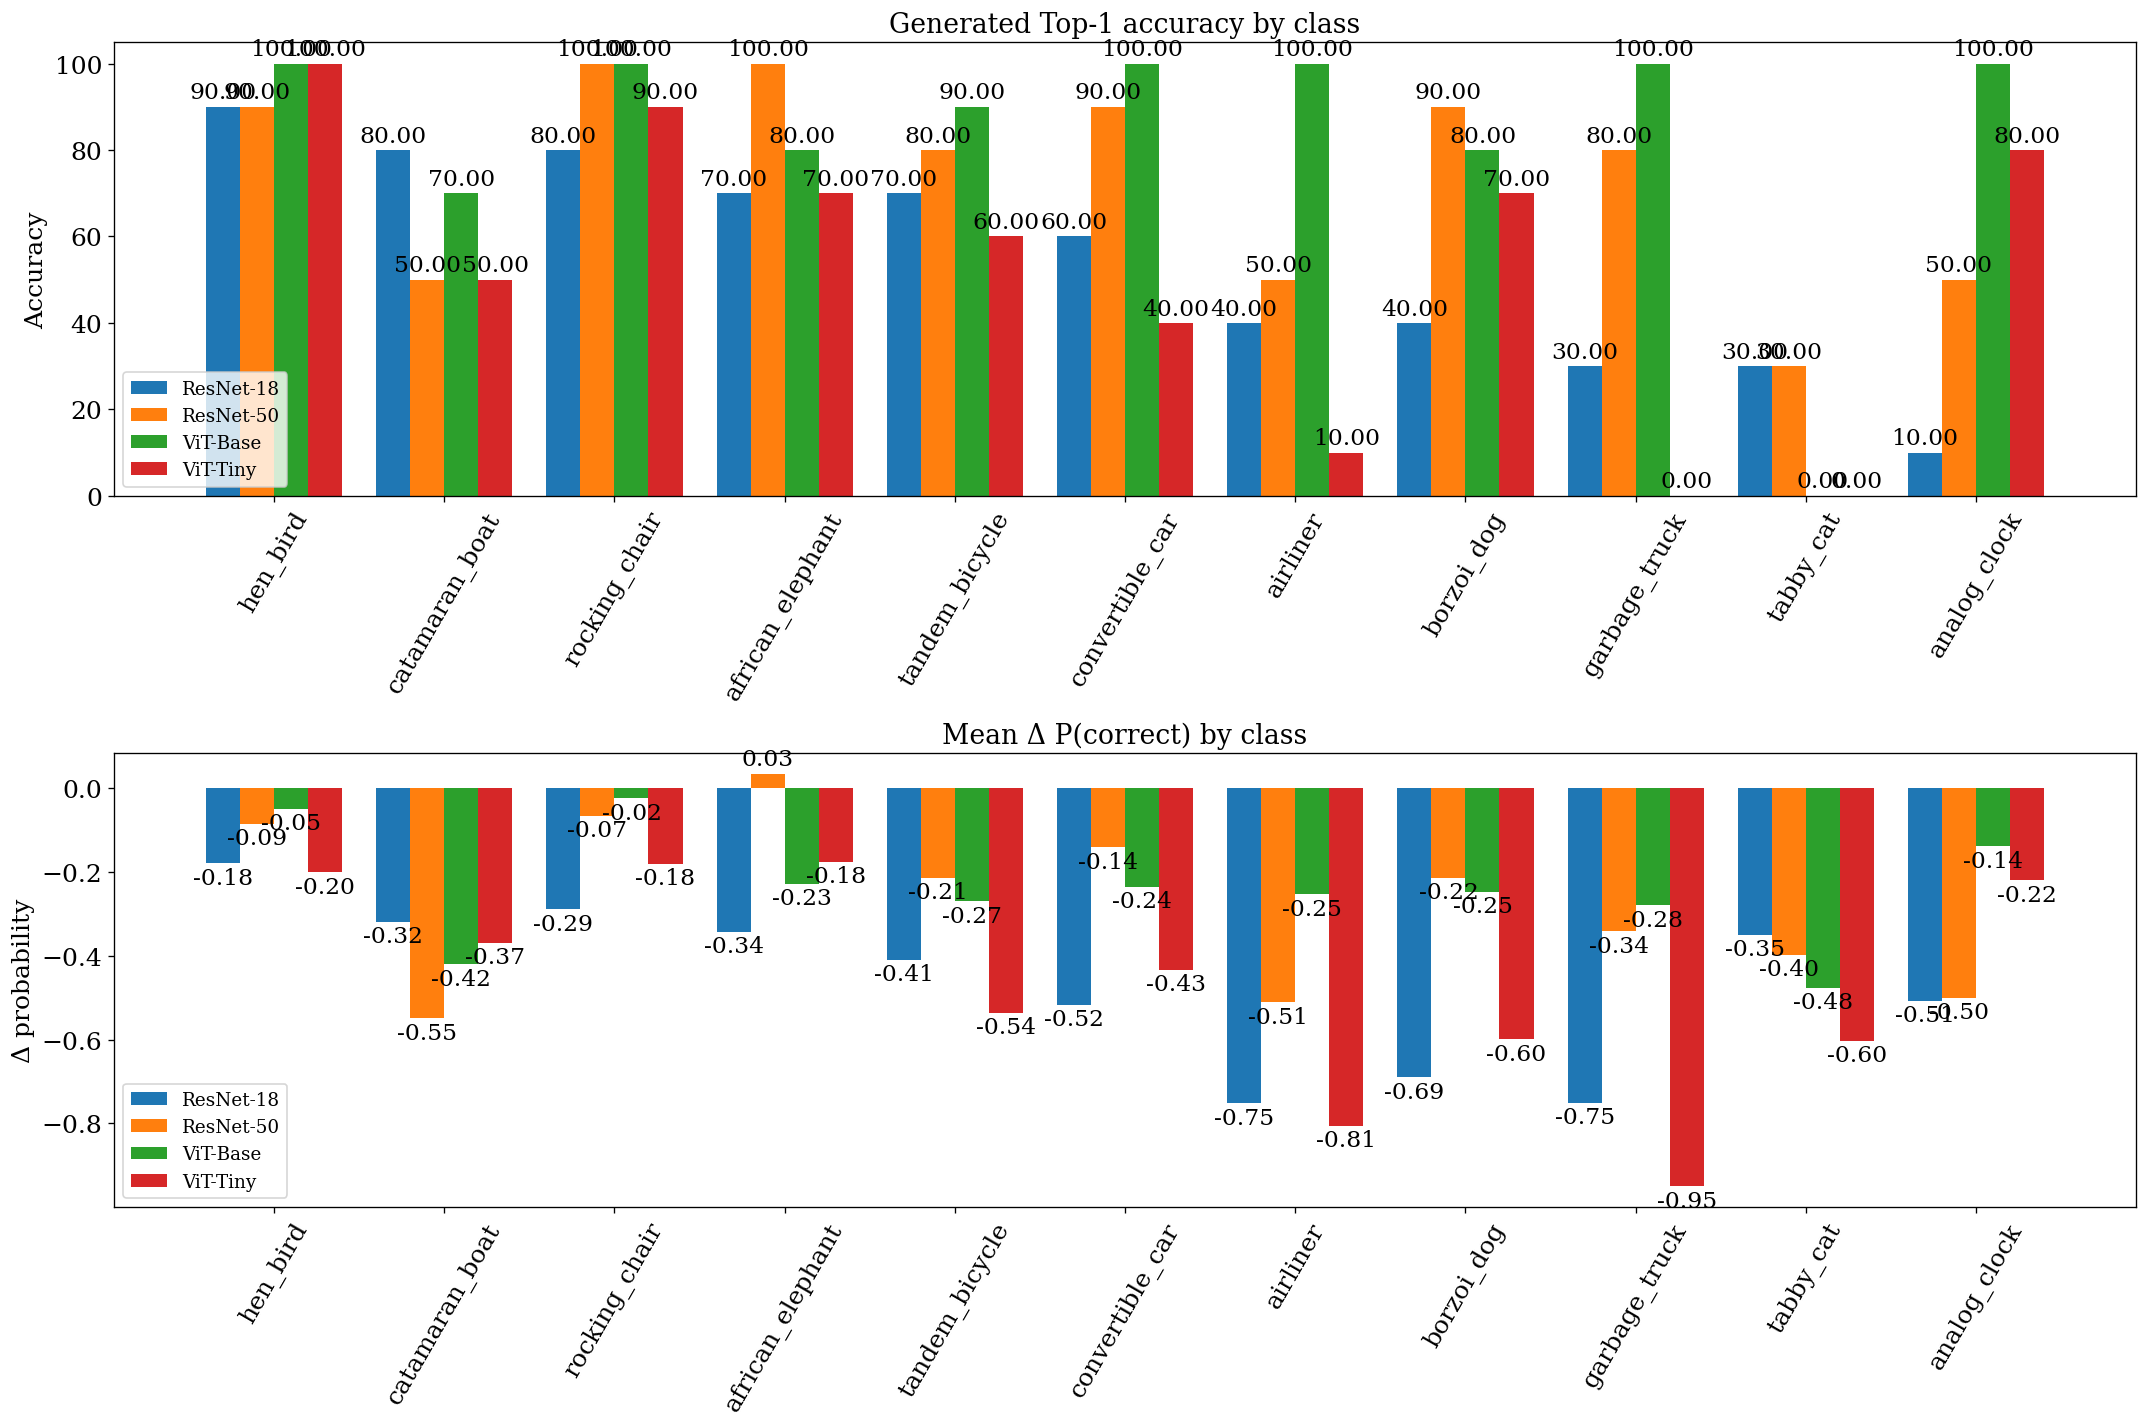

In [15]:

# Keep class-wise figure readable: use the class order from the reference metric
class_order = sort_classes_by_reference_metric(class_model, metric="generated_top1_acc")

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

grouped_bar(
    axes[0],
    class_order,
    {
        model: {
            row["class_name"]: row["generated_top1_acc"]
            for _, row in class_model[class_model["model_display"] == model].iterrows()
        }
        for model in sorted(class_model["model_display"].unique())
    },
    title="Generated Top-1 accuracy by class",
    ylabel="Accuracy",
    ylim=(0, 105),
    as_percent=True,
    rotation=60,
)

grouped_bar(
    axes[1],
    class_order,
    {
        model: {
            row["class_name"]: row["mean_delta_prob_correct"]
            for _, row in class_model[class_model["model_display"] == model].iterrows()
        }
        for model in sorted(class_model["model_display"].unique())
    },
    title="Mean Δ P(correct) by class",
    ylabel="Δ probability",
    rotation=60,
)

plt.tight_layout()

if SAVE_FIGURES:
    save_figure(fig, "fig_classwise_model_comparison")
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)


#### Best / worst classes per model

In [17]:

rows = []
for model in sorted(class_model["model_display"].unique()):
    part = class_model[class_model["model_display"] == model].sort_values("generated_top1_acc", ascending=False)
    best3 = part.head(3)[["class_name", "generated_top1_acc", "mean_delta_prob_correct"]].copy()
    worst3 = part.tail(3)[["class_name", "generated_top1_acc", "mean_delta_prob_correct"]].copy()

    for rank, (_, r) in enumerate(best3.iterrows(), start=1):
        rows.append({
            "model_display": model,
            "bucket": "best",
            "rank": rank,
            "class_name": r["class_name"],
            "generated_top1_acc": r["generated_top1_acc"],
            "mean_delta_prob_correct": r["mean_delta_prob_correct"],
        })

    for rank, (_, r) in enumerate(worst3.iterrows(), start=1):
        rows.append({
            "model_display": model,
            "bucket": "worst",
            "rank": rank,
            "class_name": r["class_name"],
            "generated_top1_acc": r["generated_top1_acc"],
            "mean_delta_prob_correct": r["mean_delta_prob_correct"],
        })

best_worst_df = pd.DataFrame(rows)
display(best_worst_df)
save_table(best_worst_df, "best_and_worst_classes_per_model")


,model_display,bucket,rank,class_name,generated_top1_acc,mean_delta_prob_correct
0,ResNet-18,best,1,hen_bird,0.9,-0.179821
1,ResNet-18,best,2,catamaran_boat,0.8,-0.319196
2,ResNet-18,best,3,rocking_chair,0.8,-0.289076
3,ResNet-18,worst,1,garbage_truck,0.3,-0.750646
4,ResNet-18,worst,2,tabby_cat,0.3,-0.350230
5,ResNet-18,worst,3,analog_clock,0.1,-0.508196
6,ResNet-50,best,1,african_elephant,1.0,0.033847
7,ResNet-50,best,2,rocking_chair,1.0,-0.066573
8,ResNet-50,best,3,borzoi_dog,0.9,-0.215073
9,ResNet-50,worst,1,airliner,0.5,-0.510950


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/best_and_worst_classes_per_model.csv


#### Compact report tables

In [18]:

report_overall = overall_model[[
    "model_display",
    "n",
    "original_top1_acc",
    "generated_top1_acc",
    "delta_top1_acc",
    "original_top5_acc",
    "generated_top5_acc",
    "delta_top5_acc",
    "mean_delta_prob_correct",
    "pred_changed_rate",
]].copy()

report_background = background_model[[
    "background_name",
    "model_display",
    "n",
    "generated_top1_acc",
    "generated_top5_acc",
    "mean_delta_prob_correct",
    "pred_changed_rate",
]].copy()

display(report_overall)
display(report_background)

save_table(report_overall, "report_overall")
save_table(report_background, "report_background")


,model_display,n,original_top1_acc,generated_top1_acc,delta_top1_acc,original_top5_acc,generated_top5_acc,delta_top5_acc,mean_delta_prob_correct,pred_changed_rate
0,ViT-Base,110,1.0,0.836364,-0.163636,1.0,0.981818,-0.018182,-0.238743,0.163636
1,ResNet-50,110,1.0,0.736364,-0.263636,1.0,0.954545,-0.045455,-0.271697,0.263636
2,ResNet-18,110,1.0,0.545455,-0.454545,1.0,0.854545,-0.145455,-0.464512,0.454545
3,ViT-Tiny,110,1.0,0.518182,-0.481818,1.0,0.772727,-0.227273,-0.461491,0.481818


,background_name,model_display,n,generated_top1_acc,generated_top5_acc,mean_delta_prob_correct,pred_changed_rate
0,openwater,ViT-Base,55,0.836364,0.981818,-0.279255,0.163636
1,openwater,ResNet-50,55,0.727273,0.927273,-0.320700,0.272727
2,openwater,ViT-Tiny,55,0.527273,0.727273,-0.489575,0.472727
3,openwater,ResNet-18,55,0.436364,0.800000,-0.544891,0.563636
4,surface,ViT-Base,55,0.836364,0.981818,-0.198230,0.163636
5,surface,ResNet-50,55,0.745455,0.981818,-0.222695,0.254545
6,surface,ResNet-18,55,0.654545,0.909091,-0.384133,0.345455
7,surface,ViT-Tiny,55,0.509091,0.818182,-0.433406,0.490909


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/report_overall.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/report_background.csv


#### Optional: export rounded tables for thesis

In [19]:

rounded_overall = report_overall.copy()
for c in rounded_overall.columns:
    if c not in ["model_display", "n"]:
        rounded_overall[c] = rounded_overall[c].round(3)

rounded_background = report_background.copy()
for c in rounded_background.columns:
    if c not in ["background_name", "model_display", "n"]:
        rounded_background[c] = rounded_background[c].round(3)

display(rounded_overall)
display(rounded_background)

save_table(rounded_overall, "report_overall_rounded")
save_table(rounded_background, "report_background_rounded")


,model_display,n,original_top1_acc,generated_top1_acc,delta_top1_acc,original_top5_acc,generated_top5_acc,delta_top5_acc,mean_delta_prob_correct,pred_changed_rate
0,ViT-Base,110,1.0,0.836,-0.164,1.0,0.982,-0.018,-0.239,0.164
1,ResNet-50,110,1.0,0.736,-0.264,1.0,0.955,-0.045,-0.272,0.264
2,ResNet-18,110,1.0,0.545,-0.455,1.0,0.855,-0.145,-0.465,0.455
3,ViT-Tiny,110,1.0,0.518,-0.482,1.0,0.773,-0.227,-0.461,0.482


,background_name,model_display,n,generated_top1_acc,generated_top5_acc,mean_delta_prob_correct,pred_changed_rate
0,openwater,ViT-Base,55,0.836,0.982,-0.279,0.164
1,openwater,ResNet-50,55,0.727,0.927,-0.321,0.273
2,openwater,ViT-Tiny,55,0.527,0.727,-0.490,0.473
3,openwater,ResNet-18,55,0.436,0.800,-0.545,0.564
4,surface,ViT-Base,55,0.836,0.982,-0.198,0.164
5,surface,ResNet-50,55,0.745,0.982,-0.223,0.255
6,surface,ResNet-18,55,0.655,0.909,-0.384,0.345
7,surface,ViT-Tiny,55,0.509,0.818,-0.433,0.491


Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/report_overall_rounded.csv
Saved: /data/local/rgaisina/experiments_final/object_relocation_background_shift/eval_results_1/report_background_rounded.csv
